In [ ]:
import pandas as pd

#Poner en <None> cuando ya no se quiera utilizar una misma semilla
rand_state = 42
data_train = pd.read_csv("../data/training.csv", index_col="EventId")


X_train = data_train.drop(['Weight', 'Label'], axis=1)

# Convertimos a 1 si es 's' (aparece tau) y 0 si es 'b' (no aparece)
y_train = (data_train['Label'] == 's').astype(int)

In [ ]:
X_train.head()

In [ ]:
#Nombres, tipos de features y cantidad de NO-nulos
X_train.info(verbose=True, show_counts=True)


#Lo demas
X_train.describe()


In [ ]:
#Graficamos cada feature como histograma (Toda feature es numerica)

#Utilizamos una parte de todo X_train por cuestiones de rendimiento
#50000 es un buen candidato por la Ley de los grandes nros. + Teo. Central Limite
X_sample = X_train.sample(n=50000, random_state=rand_state)

import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos una rejilla de gráficos
plt.figure(figsize=(15, 20))
for i, col in enumerate(X_sample.columns):
    plt.subplot(len(X_sample.columns) // 3 + 1, 3, i + 1)
    sns.histplot(X_sample[col], kde=True) # kde=True dibuja la curva de la distribución
    plt.title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

In [ ]:
#Graficamos cada feature como histograma separando por clase

#Utilizamos una parte de todo X_train por cuestiones de rendimiento
X_sample = X_train.sample(n=50000, random_state=rand_state)
y_sample = y_train.loc[X_sample.index]

df_sample = X_sample.copy()
df_sample['target'] = y_sample

import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos una rejilla de gráficos
plt.figure(figsize=(15, 20))
for i, col in enumerate(X_sample.columns):
    plt.subplot(len(X_sample.columns) // 3 + 1, 3, i + 1)
    sns.histplot(data=df_sample, x=col, hue='target', kde=True)
    plt.title(f'Distribución de {col} por clase')

plt.tight_layout()
plt.show()

In [ ]:
#Graficamos cada feature como histograma separando por PRI_jet_num

#Utilizamos una parte de todo X_train por cuestiones de rendimiento
X_sample = X_train.sample(n=50000, random_state=rand_state)

df_sample = X_sample.copy()

import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos una rejilla de gráficos
plt.figure(figsize=(15, 20))
for i, col in enumerate(X_sample.columns):
    plt.subplot(len(X_sample.columns) // 3 + 1, 3, i + 1)
    sns.histplot(data=df_sample, x=col, hue='PRI_jet_num', kde=True)
    plt.title(f'Distribución de {col} por PRI_jet_num')

plt.tight_layout()
plt.show()

In [ ]:
#Creamos la matriz de correlacion respecto a la feature objetivo
df_temp = X_train.copy()
df_temp['target'] = y_train
matriz_corr = df_temp.corr()

matriz_corr

In [ ]:
from sklearn.feature_selection import mutual_info_classif

#Correlacion entre el target y cada feature
feature_importance = mutual_info_classif(X_train, y_train, random_state=rand_state)

obj_feature_importance = pd.Series(feature_importance, index=X_train.columns)
print(obj_feature_importance.sort_values(ascending=False))


#Una vez analizada la matriz de correlacion y la escala de Mutual Info.
#Evaluar si imprimir graficas de correlacion para las features mas relevantes

In [ ]:
#Identificar posibles features mezcladas
#Identificar transformaciones para las features, como reescalarlas, estandarizarlas
#o centrar su distribucion con log(.) o sqrt(.)
 

In [ ]:
X_train.columns

In [ ]:
for feature in X_train.columns:
    print(f'La feature {feature} tiene {(X_train[feature] == -999).sum()} valores faltantes')

In [ ]:
print((y_train == 1).sum()/y_train.count(), y_train.count())

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Tomamos solo 4 eventos al azar para verlos individualmente, no mezclados
sample_events = X_train.sample(n=4)

# Creamos una cuadrícula de 2x2 gráficos
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (event_id, row) in enumerate(sample_events.iterrows()):
    ax = axes[idx]
    
    # Variables para guardar las posiciones y luego unirlas
    tau_coords = None
    lep_coords = None
    
    # 1. Graficar Tau (triángulo rojo)
    if row['PRI_tau_eta'] != -999:
        tau_coords = (row['PRI_tau_phi'], row['PRI_tau_eta'])
        ax.scatter(*tau_coords, c='red', label='Tau', s=100, marker='^')
    
    # 2. Graficar Lepton (círculo azul)
    if row['PRI_lep_eta'] != -999:
        lep_coords = (row['PRI_lep_phi'], row['PRI_lep_eta'])
        ax.scatter(*lep_coords, c='blue', label='Lepton', s=100, marker='o')
        
    # 3. LA MAGIA: Dibujar una línea entre Tau y Lepton si ambos existen
    if tau_coords and lep_coords:
        ax.plot([tau_coords[0], lep_coords[0]], 
                [tau_coords[1], lep_coords[1]], 
                color='gray', linestyle='--', alpha=0.6)
    
    # 4. Graficar Jets (cuadrados verdes)
    if row['PRI_jet_num'] >= 1 and row['PRI_jet_leading_eta'] != -999:
        ax.scatter(row['PRI_jet_leading_phi'], row['PRI_jet_leading_eta'], 
                   c='green', label='Jet 1', s=80, marker='s')
    
    if row['PRI_jet_num'] >= 2 and row['PRI_jet_subleading_eta'] != -999:
        ax.scatter(row['PRI_jet_subleading_phi'], row['PRI_jet_subleading_eta'], 
                   c='lightgreen', label='Jet 2', s=80, marker='s')

    # Configuración visual de cada cuadrito
    ax.set_xlabel('Phi (Ángulo)')
    ax.set_ylabel('Eta (Pseudorapidez)')
    ax.set_title(f'Evento ID: {event_id}')
    ax.set_xlim(-np.pi, np.pi) # Phi siempre va de -pi a pi
    ax.set_ylim(-3, 3)         # Eta suele concentrarse aquí
    ax.grid(True, alpha=0.3)
    
    if idx == 0:
        ax.legend()

plt.tight_layout()
plt.show()

Valores encontrados en Label: [1 0]


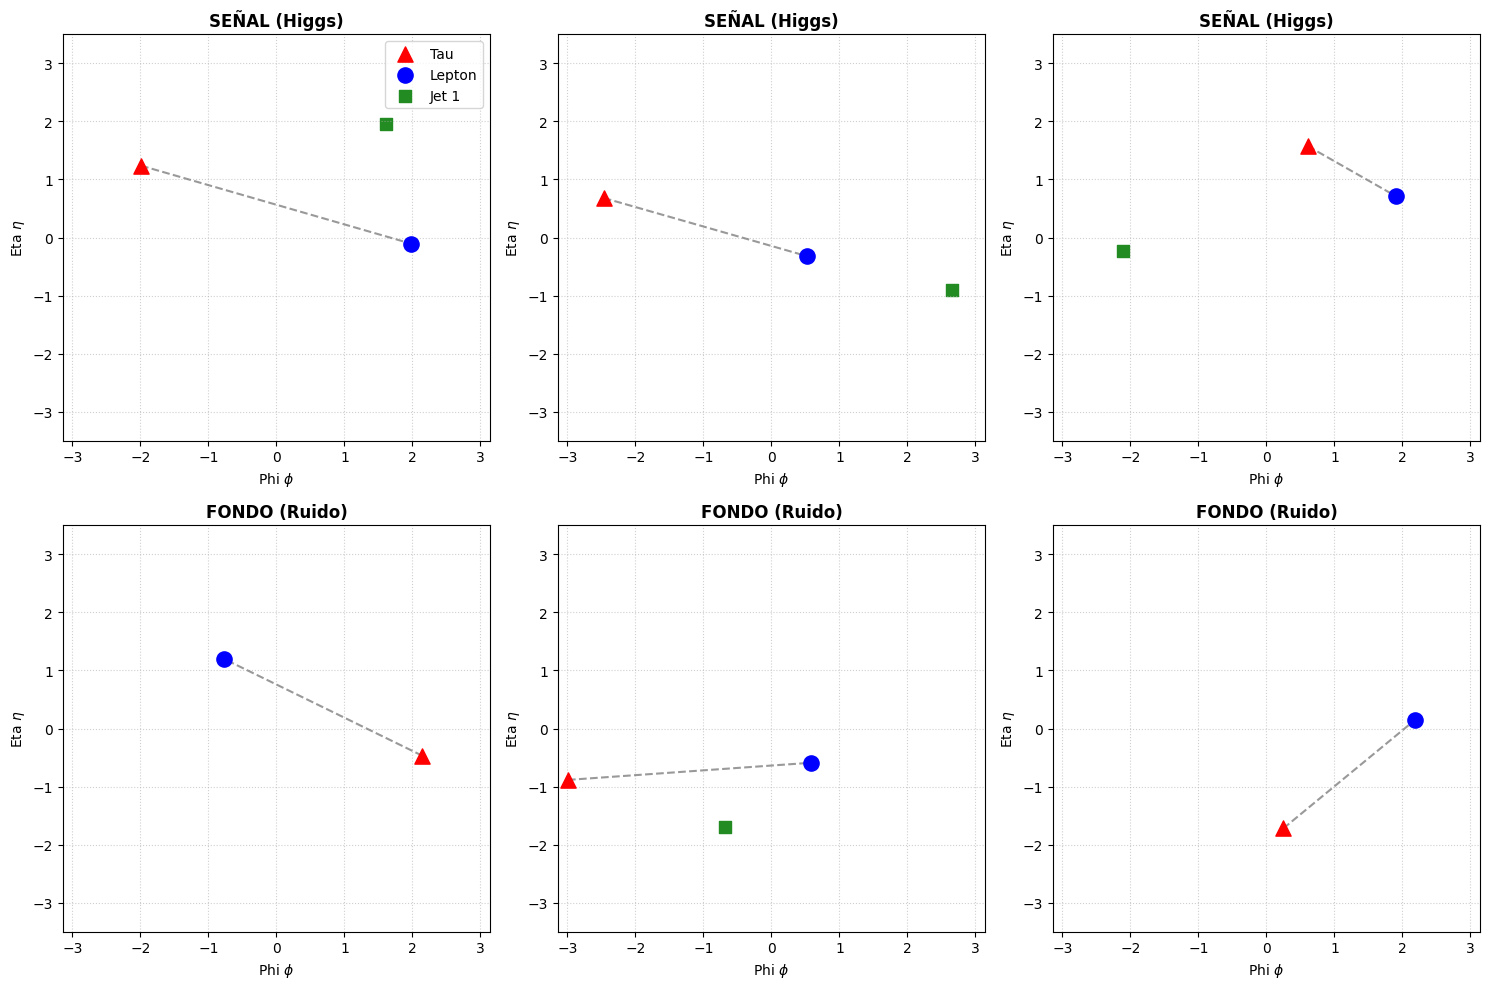

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Preparar df_plot asegurando que tenemos etiquetas
df_plot = X_train.copy()
if 'Label' not in df_plot.columns:
    df_plot['Label'] = y_train

# --- DETECTIVE DE ETIQUETAS ---
# Buscamos qué valores existen en la columna Label
valores_unicos = df_plot['Label'].unique()
print(f"Valores encontrados en Label: {valores_unicos}")

# Identificamos cuál es señal y cuál es fondo
# (El Higgs suele ser 's' o 1, el fondo 'b' o 0)
label_s = 's' if 's' in valores_unicos else 1
label_b = 'b' if 'b' in valores_unicos else 0
# ------------------------------

# 2. Separar y muestrear (con chequeo de seguridad)
try:
    signal_events = df_plot[df_plot['Label'] == label_s].sample(n=3, random_state=42)
    background_events = df_plot[df_plot['Label'] == label_b].sample(n=3, random_state=42)
    
    events_to_plot = [row for _, row in signal_events.iterrows()] + \
                     [row for _, row in background_events.iterrows()]

    # 3. Graficar
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx, row in enumerate(events_to_plot):
        ax = axes[idx]
        tau_coords, lep_coords = None, None
        
        if row['PRI_tau_eta'] != -999:
            tau_coords = (row['PRI_tau_phi'], row['PRI_tau_eta'])
            ax.scatter(*tau_coords, c='red', label='Tau', s=120, marker='^', zorder=3)
        
        if row['PRI_lep_eta'] != -999:
            lep_coords = (row['PRI_lep_phi'], row['PRI_lep_eta'])
            ax.scatter(*lep_coords, c='blue', label='Lepton', s=120, marker='o', zorder=3)
            
        if tau_coords and lep_coords:
            ax.plot([tau_coords[0], lep_coords[0]], [tau_coords[1], lep_coords[1]], 
                    color='gray', linestyle='--', alpha=0.8)
        
        if row['PRI_jet_num'] >= 1 and row['PRI_jet_leading_eta'] != -999:
            ax.scatter(row['PRI_jet_leading_phi'], row['PRI_jet_leading_eta'], 
                       c='forestgreen', label='Jet 1', s=80, marker='s')

        tipo = "SEÑAL (Higgs)" if idx < 3 else "FONDO (Ruido)"
        ax.set_title(f'{tipo}', fontweight='bold')
        ax.set_xlabel(r'Phi $\phi$')
        ax.set_ylabel(r'Eta $\eta$')
        ax.set_xlim(-np.pi, np.pi)
        ax.set_ylim(-3.5, 3.5)
        ax.grid(True, linestyle=':', alpha=0.6)
        if idx == 0: ax.legend()

    plt.tight_layout()
    plt.show()

except ValueError as e:
    print(f"Error: No hay suficientes muestras. ¿Seguro que tienes al menos 3 de cada tipo?")
    print(f"Conteo actual:\n{df_plot['Label'].value_counts()}")